# What the Sharpe Ratio Cannot See

This notebook goes with the post *Two Portfolios, One Score*.

**The claim.** The Sharpe ratio is built from the average and the standard
deviation of a set of returns. Neither of those depends on the order the returns
arrive in. So you can shuffle a year of daily returns into a completely different
sequence and the Sharpe ratio does not move at all.

But the experience of holding that investment changes completely. In one order the
bad days are scattered around. In another they land on top of each other and you
sit through a fall you might not survive.

**The test.** Take real daily returns. Shuffle them ten thousand times. Check that
the Sharpe ratio is identical every time. Then look at how much the worst decline
varies across those same shuffles.

Run this top to bottom on a fresh kernel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
print(f"python {sys.version.split()[0]}")
print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")

python 3.12.2
numpy  1.26.4
pandas 2.2.2


## The data

Daily returns on the S&P 500 from the start of 2007 to the end of 2009. I picked
that window deliberately because it contains the 2008 crash, so there is a real
decline to look at rather than a made up one.

If `yfinance` is not installed, run `pip install yfinance` first. Yahoo changes
things periodically and this download does break from time to time, so the cell
below saves a local copy the first time it works. After that it reads the copy.

In [3]:
import yfinance as yf
from pathlib import Path

CACHE = Path("sp500_2007_2009.csv")

if CACHE.exists():
    prices = pd.read_csv(CACHE, index_col=0, parse_dates=True).squeeze()
else:
    raw = yf.download("^GSPC", start="2007-01-01", end="2009-12-31",
                      auto_adjust=True, progress=False)
    prices = raw["Close"].squeeze()
    prices.to_csv(CACHE)

returns = prices.pct_change().dropna()

print(f"{len(returns)} trading days")
print(f"{returns.index[0].date()} to {returns.index[-1].date()}")
returns.head()

754 trading days
2007-01-04 to 2009-12-30


Date
2007-01-04    0.001228
2007-01-05   -0.006085
2007-01-08    0.002220
2007-01-09   -0.000517
2007-01-10    0.001940
Name: ^GSPC, dtype: float64

## The Sharpe ratio

The Sharpe ratio asks how much return you got for each unit of volatility you put
up with. You take the average return, subtract whatever you could have earned
risk free, and divide by the standard deviation of the returns.

I am setting the risk free rate to zero here. It was not zero in 2007, but adding
it in changes both portfolios by exactly the same amount and this post is about
comparing two orderings of the same numbers. Leaving it out keeps the code honest
and simple. It is the kind of assumption you should always state rather than bury.

The multiplication by the square root of 252 turns a daily figure into an annual
one, since there are about 252 trading days in a year.

In [4]:
TRADING_DAYS = 252

def sharpe_ratio(returns, risk_free=0.0, periods=TRADING_DAYS):
    excess = returns - risk_free / periods
    return np.sqrt(periods) * excess.mean() / excess.std()


actual_sharpe = sharpe_ratio(returns)
print(f"Sharpe ratio: {actual_sharpe:.6f}")

Sharpe ratio: -0.105957


Notice there is nothing in that function that looks at position. `mean` and `std`
both take a bag of numbers and hand back a summary. Neither of them can tell you
whether the worst day came first or last.

## Maximum drawdown

Drawdown is the measure that does care about order. It asks: starting from the
highest point your money ever reached, how far did it fall before recovering?
The maximum drawdown is the worst of those falls over the whole period.

The calculation is three steps. Turn the returns into a running value of your
money. Track the highest point reached so far. Then measure how far below that
high water mark you are on each day, and take the worst.

In [5]:
def equity_curve(returns):
    """Value of 1 unit of money over time."""
    return (1 + returns).cumprod()


def max_drawdown(returns):
    """Worst peak to trough fall, as a negative number."""
    curve = equity_curve(returns)
    running_peak = np.maximum.accumulate(curve)
    drawdowns = curve / running_peak - 1
    return drawdowns.min()


actual_dd = max_drawdown(returns)
print(f"Maximum drawdown: {actual_dd:.1%}")

Maximum drawdown: -56.8%


## One shuffle

Now take exactly the same daily returns and deal them out in a different order.
Not different numbers. The same numbers, rearranged.

In [6]:
rng = np.random.default_rng(42)

shuffled = pd.Series(
    rng.permutation(returns.values),
    index=returns.index,
)

print(f"{'':22} {'real':>12} {'shuffled':>12}")
print(f"{'Sharpe ratio':22} {sharpe_ratio(returns):>12.6f} {sharpe_ratio(shuffled):>12.6f}")
print(f"{'Total return':22} {equity_curve(returns).iloc[-1] - 1:>11.1%} {equity_curve(shuffled).iloc[-1] - 1:>11.1%}")
print(f"{'Maximum drawdown':22} {max_drawdown(returns):>11.1%} {max_drawdown(shuffled):>11.1%}")

                               real     shuffled
Sharpe ratio              -0.105957    -0.105957
Total return                -20.5%      -20.5%
Maximum drawdown            -56.8%      -49.5%


The Sharpe ratio matches to six decimal places, because it is the same numbers in
a different order and the formula cannot tell the difference.

So does the total return, and for a slightly different reason. Your final amount
is every daily return multiplied together, and multiplication does not care about
order. Two times three is the same as three times two. So you end the period with
exactly the same amount of money either way.

Same final wealth. Same Sharpe ratio. The drawdown is the only one of the three
that moves, because it is the only one that asks what happened along the way.

## What that looks like

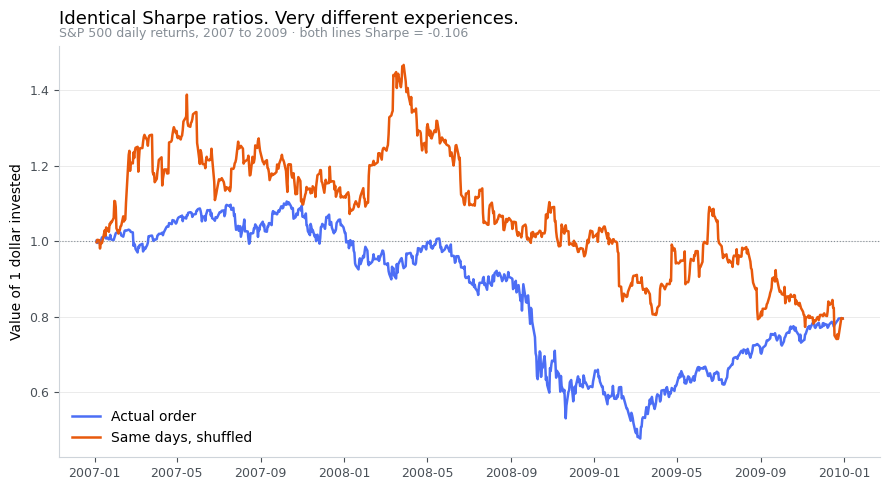

In [7]:
REAL, SHUF, GREY, INK = "#4C6EF5", "#E8590C", "#868E96", "#212529"

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(returns.index, equity_curve(returns).values,
        color=REAL, linewidth=1.8, label="Actual order", zorder=3)
ax.plot(returns.index, equity_curve(shuffled).values,
        color=SHUF, linewidth=1.8, label="Same days, shuffled", zorder=3)

ax.axhline(1.0, color=GREY, linewidth=0.8, linestyle=":", zorder=1)

ax.set_ylabel("Value of 1 dollar invested", fontsize=10)
ax.set_title("Identical Sharpe ratios. Very different experiences.",
             fontsize=13, pad=16, loc="left")
ax.text(0, 1.015,
        f"S&P 500 daily returns, 2007 to 2009 · both lines Sharpe = {actual_sharpe:.3f}",
        transform=ax.transAxes, fontsize=9, color=GREY, va="bottom")

ax.legend(frameon=False, fontsize=10, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CED4DA")
ax.tick_params(colors="#495057", labelsize=9)
ax.grid(axis="y", alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("equity_curves.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

Both lines are made of exactly the same daily returns. Both have the same Sharpe
ratio. One of them contains the 2008 crash. The other spreads those same bad days
across three years so they never pile up.

## Ten thousand shuffles

One shuffle could be a fluke. Ten thousand tells you the range of experiences
hiding behind that single Sharpe number.

This loop takes a little while. It is doing ten thousand full drawdown
calculations on about 750 days each.

In [8]:
N_SHUFFLES = 10_000
vals = returns.values

dd_samples = np.empty(N_SHUFFLES)
sharpe_samples = np.empty(N_SHUFFLES)

for i in range(N_SHUFFLES):
    s = pd.Series(rng.permutation(vals))
    dd_samples[i] = max_drawdown(s)
    sharpe_samples[i] = sharpe_ratio(s)

print(f"done, {N_SHUFFLES:,} shuffles")

done, 10,000 shuffles


In [9]:
print("Sharpe ratio across all shuffles")
print(f"  min  {sharpe_samples.min():.10f}")
print(f"  max  {sharpe_samples.max():.10f}")
print(f"  spread {sharpe_samples.max() - sharpe_samples.min():.2e}")
print()
print("Maximum drawdown across all shuffles")
print(f"  best   {dd_samples.max():.1%}")
print(f"  worst  {dd_samples.min():.1%}")
print(f"  median {np.median(dd_samples):.1%}")
print(f"  actual {actual_dd:.1%}")

Sharpe ratio across all shuffles
  min  -0.1059568494
  max  -0.1059568494
  spread 2.91e-16

Maximum drawdown across all shuffles
  best   -26.5%
  worst  -72.2%
  median -47.7%
  actual -56.8%


The Sharpe spread should come out at around 1e-15, which is not a real difference.
That is floating point arithmetic, the tiny rounding error computers carry when
they add up the same numbers in a different order. For every practical purpose the
Sharpe ratio is constant.

The drawdown is not constant at all.

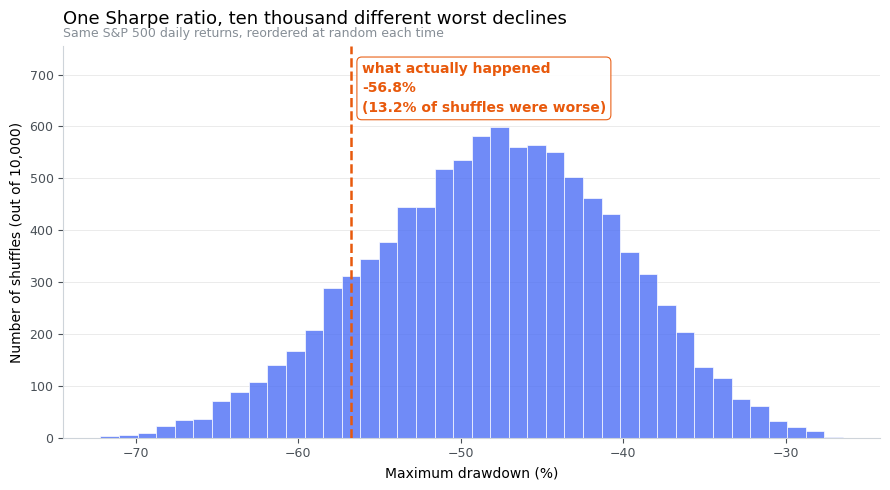

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(dd_samples * 100, bins=40, color=REAL, alpha=0.8,
        edgecolor="white", linewidth=0.6)

ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
top = ax.get_ylim()[1]

pct = (dd_samples < actual_dd).mean() * 100

ax.axvline(actual_dd * 100, color=SHUF, linestyle="--", linewidth=1.8, zorder=3)
ax.annotate(
    f"what actually happened\n{actual_dd:.1%}\n({pct:.1f}% of shuffles were worse)",
    xy=(actual_dd * 100, top * 0.96), ha="left", va="top",
    xytext=(8, 0), textcoords="offset points",
    fontsize=10, color=SHUF, fontweight="bold", linespacing=1.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=SHUF, lw=0.8, alpha=0.95),
    zorder=4,
)

ax.set_xlabel("Maximum drawdown (%)", fontsize=10)
ax.set_ylabel(f"Number of shuffles (out of {N_SHUFFLES:,})", fontsize=10)
ax.set_title("One Sharpe ratio, ten thousand different worst declines",
             fontsize=13, pad=16, loc="left")
ax.text(0, 1.015,
        "Same S&P 500 daily returns, reordered at random each time",
        transform=ax.transAxes, fontsize=9, color=GREY, va="bottom")

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CED4DA")
ax.tick_params(colors="#495057", labelsize=9)
ax.grid(axis="y", alpha=0.25, linewidth=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("drawdown_distribution.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## What this does and does not show

It shows that the Sharpe ratio contains no information about sequence. Two
investments with the same Sharpe can put you through very different things, and
the number will not warn you.

It does not show that the Sharpe ratio is broken or useless. It measures return per
unit of volatility, and it measures that correctly. The problem is not the formula.
The problem is that people read it as a general summary of how risky something is,
and it was never that.

There is also something worth noticing about the real world in the chart above.
Real market returns are not shuffled. Bad days cluster together, because fear and
selling feed on each other. That clustering is exactly what the shuffling destroys,
and it is why the actual 2008 decline sits where it does relative to the random
orderings. A measure that assumes order does not matter will consistently
understate what real markets put you through.

## Takeaway

The Sharpe ratio answers one narrow question well. Report it alongside maximum
drawdown, and you have said something about both how bumpy the ride was and how
far down it went. Report it alone and you have described a year of investing with a
number that cannot tell a steady climb from a crash and a recovery.

This matters for what I am working on next. When you compare two portfolio
strategies, the Sharpe ratio is the default scoreboard. If one strategy earns its
score by grinding steadily and the other by surviving a collapse, the scoreboard
will call it a draw.